Train shape: (891, 12)
Test shape: (418, 11)

Missing values in train:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


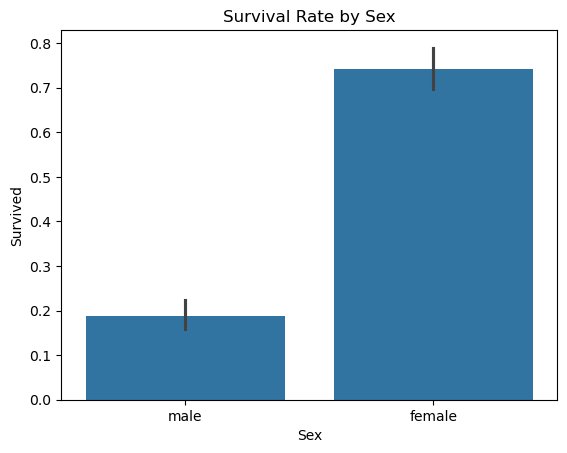

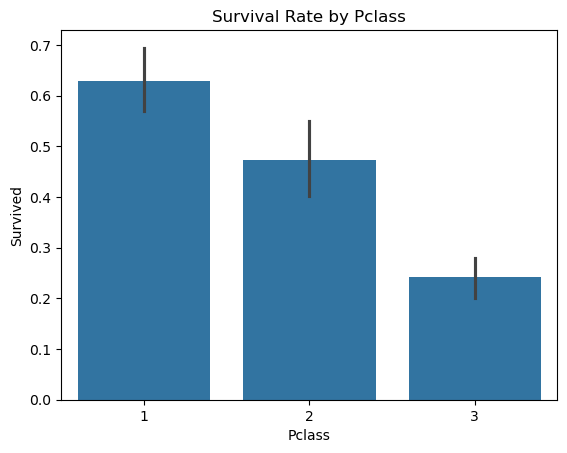

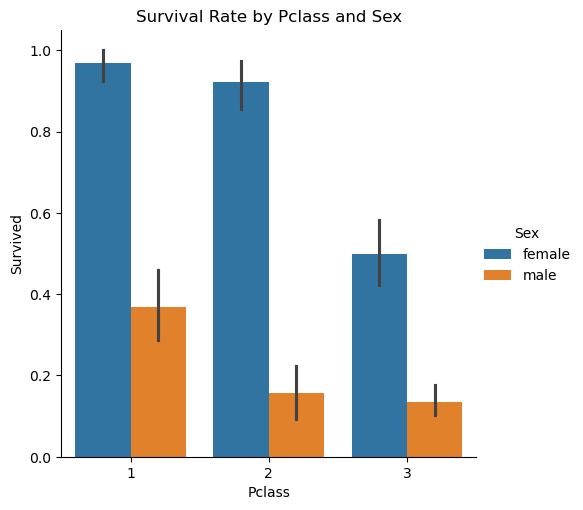

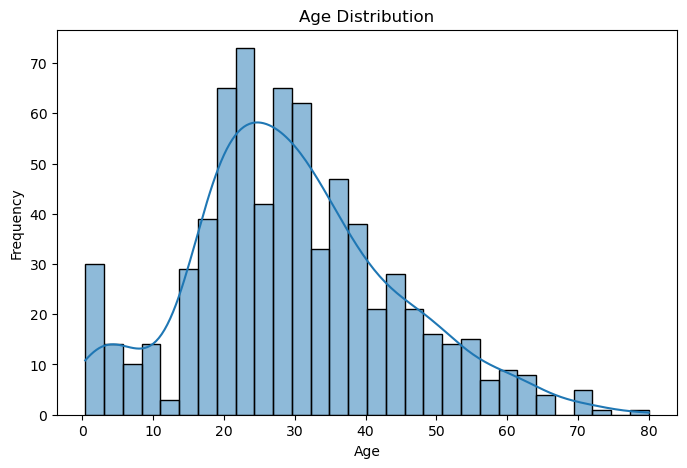

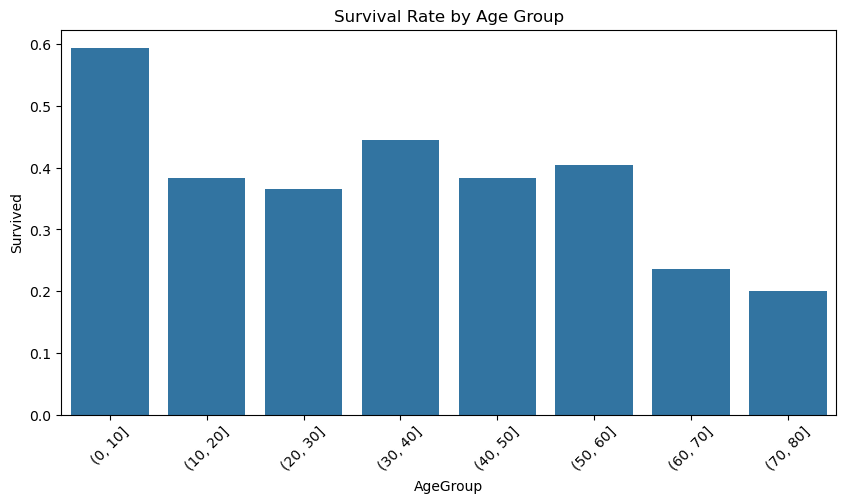

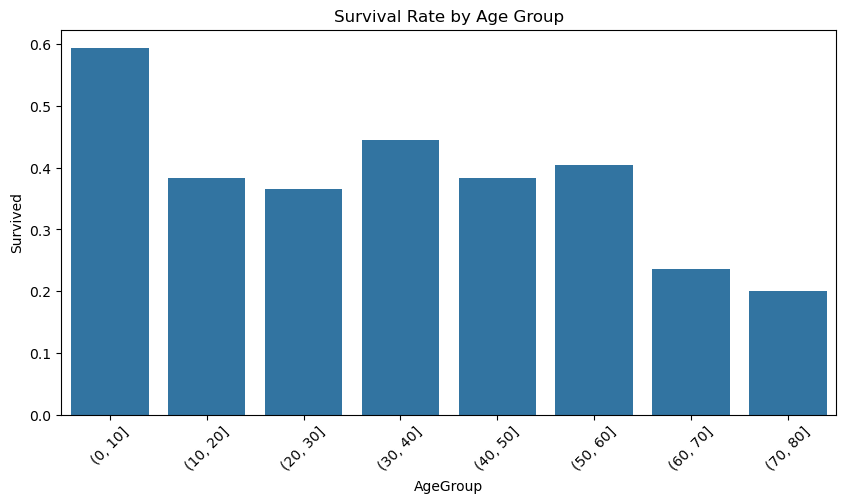

In [40]:
# Titanic - EDA & Preprocessing

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
train = pd.read_csv("../Data/train.csv")
test = pd.read_csv("../Data/test.csv")

# Quick Overview
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nMissing values in train:\n", train.isnull().sum())
print("\nMissing values in test:\n", test.isnull().sum())

# Sample preview
train.head()

# Analyze survival rate by Sex using bar plot
sns.barplot(x="Sex", y="Survived", data=train)

# Set the plot title
plt.title("Survival Rate by Sex")

# Display the plot
plt.show()

# Analyze survival rate by Pclass (ticket class)
sns.barplot(x="Pclass", y="Survived", data=train)

# Set the plot title
plt.title("Survival Rate by Pclass")

# Display the plot
plt.show()

# Analyze survival rate by both Pclass and Sex using grouped bar plot
sns.catplot(x="Pclass", y="Survived", hue="Sex", data=train, kind="bar")

# Set the plot title
plt.title("Survival Rate by Pclass and Sex")

# Display the plot
plt.show()

# Plot the distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(train["Age"].dropna(), bins=30, kde=True)

# Set title and labels
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Show the plot
plt.show()

# Create age bins (0~10, 10~20, ..., 70~80)
train["AgeGroup"] = pd.cut(train["Age"], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80])

# Group by age bins and calculate survival rate (with observed=False to avoid warning)
age_group_survival = train.groupby("AgeGroup", observed=False)["Survived"].mean().reset_index()

# Plot survival rate by age group
plt.figure(figsize=(10, 5))
sns.barplot(x="AgeGroup", y="Survived", data=age_group_survival)
plt.title("Survival Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

# Plot survival rate by age group
plt.figure(figsize=(10, 5))
sns.barplot(x="AgeGroup", y="Survived", data=age_group_survival)

# Set plot title and rotate x labels
plt.title("Survival Rate by Age Group")
plt.xticks(rotation=45)

# Show the plot
plt.show()

# Fill missing Age values
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

# Fill missing Embarked value
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

# Fill missing Fare value
test["Fare"] = test["Fare"].fillna(test["Fare"].median())

# Encode 'Sex' column (male → 0, female → 1)
train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
test["Sex"] = test["Sex"].map({"male": 0, "female": 1})

# Encode 'Embarked' column using label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train["Embarked"] = le.fit_transform(train["Embarked"])
test["Embarked"] = le.transform(test["Embarked"])